# Example 2

Dynamical system is
$$ \dot x = \begin{bmatrix}
-2\lambda_2x_2(x_1^2 - x_2 -2x_1x_2 + x_2^4) + \lambda_1(x_1+4x_1^2x_2 - x_2^2 - 8x_1x_2^3 + 4x_2^5) \\
2\lambda_1(x_1-x_2^2)^2 - \lambda_2(x_1^2-x_2 -2x_1x_2^2 + x_2^4) 
\end{bmatrix}$$

In [ ]:
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt
import cvxpy as cp
import time

In [193]:
#Define Jacobian matrix E= dF(0)/dz at origin
E = np.array([[-1,0],[0,3]])
# compute eigvalues and left eigenvectors of E
e,evecL,evecR = eig(E,left=True)
# eigenvalues
eval1 = e[0].real
eval2 = e[1].real
# eigenvectors
w1 = evecL[:,0]
w2 = evecL[:,1]

In [194]:
# Define (z_1,z_2) grid
npoints = 30
x_grid = np.linspace(-1, 1, npoints)
y_grid = np.linspace(-1, 1, npoints)

X,Y = np.meshgrid(x_grid,y_grid)
XY = np.zeros((npoints**2,2))

k = 0
for i in range(npoints):
    for j in range(npoints):
        XY[k,:] = np.array([X[i,j],Y[i,j]])
        k = k+1


# Define test grids
n_test = 60
x_grid_test = np.linspace(-1, 1, n_test)
y_grid_test = np.linspace(-1, 1, n_test)

X_test,Y_test = np.meshgrid(x_grid_test,y_grid_test)
XY_test = np.zeros((n_test**2,2))

k = 0
for i in range(n_test):
    for j in range(n_test):
        XY_test[k,:] = np.array([X_test[i,j],Y_test[i,j]])
        k = k+1

In [195]:
#Define functions F and G
def F(x):
    value1 = -2*eval2*x[:,1]*(x[:,0]**2-x[:,1]-2*x[:,0]*x[:,1]**2+x[:,1]**4)+eval1*(x[:,0]+4*x[:,0]**2*x[:,1]-x[:,1]**2-8*x[:,0]*x[:,1]**3+4*x[:,1]**5)
    value2 = 2*eval1*(x[:,0]-x[:,1]**2)**2-eval2*(x[:,0]**2-x[:,1]-2*x[:,0]*x[:,1]**2+x[:,1]**4)
    return np.array([value1, value2]).T

def G(x):
    value = np.zeros((len(x),2))
    for i in range(len(x)):
        value[i,:] = np.dot(E, x[i,:])
    value = F(x)-value
    return value

In [196]:
# define eigenfunctions
def phi_1(X):
    return X[:,0] - X[:,1]**2

def phi_2(X):
    return -X[:,0]**2 + X[:,1] + 2 * X[:,0] * X[:,1]**2 - X[:,1] ** 4

In [197]:
# copute F and G at mesh grids
F_val = F(XY)
G_val = G(XY)

In [198]:
# define some functions
def RHS(npoints, w):
    
    # right-hand side
    y0 = np.zeros((3,1))
    y1 = np.zeros((npoints**2,1))
    for i in range(npoints**2):
        y1[i] = -G_val[i,:] @ w
    y = np.row_stack((y0,y1))
    return y



def Measurements(npoints, N, gamma, eig_val, XY_test):
    
    # random feature matrix
    Omega = np.random.normal(0, np.sqrt(2*gamma), size=(2,N) )
    # random bias
    random_bias = np.random.uniform(-np.pi, np.pi, size=(N,))
    # temp matrix
    A_0 = np.cos(random_bias)
    B_0 = np.sin(random_bias)
    # generate amtrix A
    A = np.zeros((npoints**2+3,N))
    A[0,:] = A_0                   # h(0) = 0
    A[1:3,:] = B_0 * Omega         # h'(0) = 0
    # linear pde
    A[3:,:] = - F_val @ Omega * np.sin(XY @ Omega + random_bias) - eig_val * np.cos(XY @ Omega + random_bias) 
    
    # estimate non-linear function h at mesh grids
    K = np.cos(XY_test @ Omega + random_bias)
    
    return A, K  

#### Estimate eigenfunction $\phi_{\lambda_1}$

In [199]:
# number of features
N_range = [100,200,400,800,1600]
# scaling parameter
gamma = 0.1
# repeat T times
T = 20
# 
error1 = [ ]

# compute RHS
y =  RHS(npoints, w1)
# compute true eigenfucntion
phi1 = phi_1(XY_test).reshape(n_test,n_test)


for N in N_range:
    rel = [ ]
    for i in range(T):
        A, K = Measurements(npoints, N, gamma, eval1, XY_test)
        # solve optimization problem
        c = np.linalg.pinv(A) @ y
        # test
        y_test = K@c
        # estimate eigenfunction
        phi_hat = y_test.reshape(n_test,n_test) + w1[0] * X_test + w1[1] * Y_test
        # compute error
        rel.append(np.sqrt(np.sum((phi_hat - phi1) ** 2) / N ) )
    error1.append(rel)

In [200]:
# number of features
N_range = [100,200,400,800,1600]
# scaling parameter
gamma = 0.1
# repeat T times
T = 20
# 
error2 = [ ]

# compute RHS
y =  RHS(npoints, w2)
# compute true eigenfucntion
phi2 = phi_2(XY_test).reshape(n_test,n_test)


for N in N_range:
    rel = [ ]
    for i in range(T):
        A, K = Measurements(npoints, N, gamma, eval2, XY_test)
        # solve optimization problem
        c = np.linalg.pinv(A) @ y
        # test
        y_test = K@c
        # estimate eigenfunction
        phi_hat = y_test.reshape(n_test,n_test) + w2[0] * X_test + w2[1] * Y_test
        # compute error
        rel.append(np.sqrt(np.sum((phi_hat - phi2) ** 2) / N ) )
    error2.append(rel)

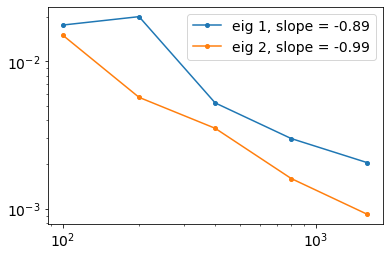

In [201]:
xxx = np.array(error1).mean(axis=1)
yyy = np.array(error2).mean(axis=1)
slope1,_ = np.polyfit(np.log(N_range), np.log(xxx), deg=1)
slope2,_ = np.polyfit(np.log(N_range), np.log(yyy), deg=1)
plt.loglog(N_range, xxx, '-o', label=f'eig 1, slope = {slope1:.2f}', markersize=4)
plt.loglog(N_range, yyy, '-o', label=f'eig 2, slope = {slope2:.2f}', markersize=4)
plt.legend(fontsize=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.savefig('N.pdf', bbox_inches = 'tight')

### Gamma

In [202]:
# number of features
N = 100
# scaling parameter
gamma_range = np.linspace(0.1,8,40)
# repeat T times
T = 10
# 
error = [ ]

# compute RHS
y =  RHS(npoints, w1)
# compute true eigenfucntion
phi1 = phi_1(XY_test).reshape(n_test,n_test)

for gamma in gamma_range:
    rel = [ ]
    for i in range(T):
        A, K = Measurements(npoints, N, gamma, eval1, XY_test)
        # solve optimization problem
        c = np.linalg.pinv(A) @ y
        # test
        y_test = K@c
        # estimate eigenfunction
        phi_hat = y_test.reshape(n_test,n_test) + w1[0] * X_test + w1[1] * Y_test
        # compute error
        rel.append(np.sum((phi_hat - phi1) ** 2) / np.sum(phi1**2) )
    error.append(rel)

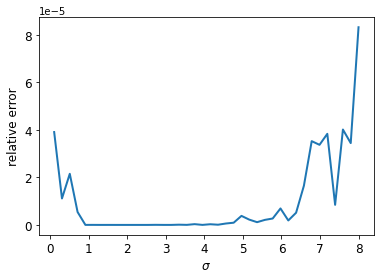

In [204]:
yyy = np.array(error).mean(axis=1)
plt.plot(gamma_range, yyy, linewidth=2)
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.xlabel(r'$\sigma$', size=12)
plt.ylabel('relative error', size=12)
plt.xticks(size=12)
plt.yticks(size=12)
plt.savefig('variance.pdf', bbox_inches = 'tight')